In [1]:
import sys; sys.path.insert(0, "..")
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

t1 = pd.read_csv("../results/task1_raw_results.csv")
t2 = pd.read_csv("../results/task2_raw_results.csv")

with open("../results/task1_metrics.json") as f: m1 = json.load(f)
with open("../results/task2_metrics.json") as f: m2 = json.load(f)

### All 4 strategies compared

In [2]:
rows = []
for label, d in [("Zero-Shot (T1)", m1["zero_shot"]),
                  ("Few-Shot (T1)",  m1["few_shot"]),
                  ("Direct (T2)",    m2["direct"]),
                  ("CoT (T2)",       m2["cot"])]:
    rows.append({"Strategy": label,
                 "Accuracy":    d["accuracy"],
                 "Macro-F1":    d["macro_f1"],
                 "Compliance":  d["format_compliance_rate"]})
pd.DataFrame(rows)

,Strategy,Accuracy,Macro-F1,Compliance
0,Zero-Shot (T1),0.6200,0.6006,1.000
1,Few-Shot (T1),0.6500,0.6390,1.000
2,Direct (T2),0.6650,0.6545,1.000
3,CoT (T2),0.6181,0.6090,0.995


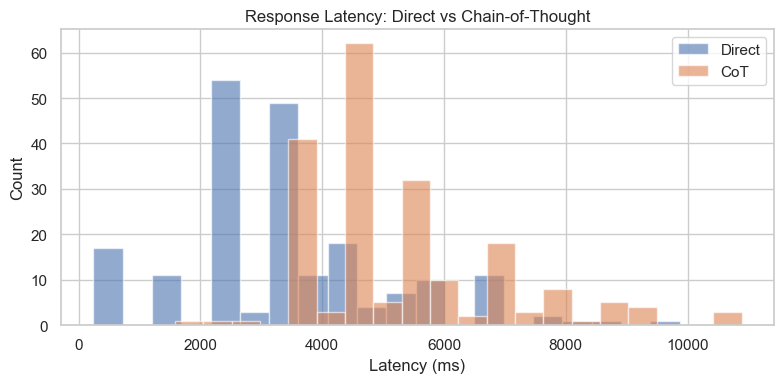

In [3]:
t2_cot    = t2[t2["prompt_type"] == "cot"]
t2_direct = t2[t2["prompt_type"] == "direct"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(t2_direct["latency_ms"], bins=20, alpha=0.6, label="Direct", color="#4C72B0")
ax.hist(t2_cot["latency_ms"],    bins=20, alpha=0.6, label="CoT",    color="#DD8452")
ax.set_xlabel("Latency (ms)"); ax.set_ylabel("Count")
ax.set_title("Response Latency: Direct vs Chain-of-Thought")
ax.legend()
plt.tight_layout()
plt.savefig("../results/task2_latency.png", dpi=150)
plt.show()

In [6]:
cot_df = t2[t2["prompt_type"] == "cot"].copy()
mismatches = cot_df[cot_df["reasoning_mismatch"] == True] if "reasoning_mismatch" in cot_df.columns else pd.DataFrame()
print(f"Reasoning mismatches: {len(mismatches)} / {len(cot_df)}")

for _, row in mismatches.head(5).iterrows():
    print(f"\n{'─'*60}")
    print(f"TRUE: {int(row['true_stars'])}★ | PRED: {int(row['pred_stars'])}★")
    print(f"REASONING: {str(row['reasoning'])[:300]}")
    print(f"REVIEW: {row['text_snippet'][:120]}")

Reasoning mismatches: 0 / 200


### Compare Both Mismatch Approaches Side by Side

In [7]:

judged = pd.read_csv("../results/task2_judged_results.csv")
cot_j = judged[judged["prompt_type"] == "cot"]

n_inconsistent = (cot_j["judge_consistent"] == False).sum()
n_evaluated = cot_j["judge_consistent"].notna().sum()

comparison = pd.DataFrame([
    {"Approach": "Keyword Heuristic (Approach 1)",
     "Mismatches Found": 0,
     "Mismatch Rate": "0.0%",
     "Limitation": "Blind to analytical reasoning vocabulary"},
    {"Approach": "LLM-as-Judge (Approach 2)",
     "Mismatches Found": int(n_inconsistent),
     "Mismatch Rate": f"{n_inconsistent/n_evaluated:.1%}",
     "Limitation": "Adds latency; judge may share model biases"},
])
print(comparison.to_string(index=False))

                      Approach  Mismatches Found Mismatch Rate                                 Limitation
Keyword Heuristic (Approach 1)                 0          0.0%   Blind to analytical reasoning vocabulary
     LLM-as-Judge (Approach 2)                39         19.6% Adds latency; judge may share model biases


### Where do mismatches cluster? (star class breakdown)

In [8]:

inconsistent = cot_j[cot_j["judge_consistent"] == False].copy()
inconsistent["pred_stars"] = inconsistent["pred_stars"].astype("Int64")
print("Mismatches by true star class:")
print(inconsistent.groupby("true_stars").size().sort_values(ascending=False))
print("\nMismatches by pred star:")
print(inconsistent.groupby("pred_stars").size().sort_values(ascending=False))

Mismatches by true star class:
true_stars
4    12
2    10
3     9
1     5
5     3
dtype: int64

Mismatches by pred star:
pred_stars
2    23
4    16
dtype: int64
